#CNN MODEL

In [12]:
#Importing Libraries
import json, os
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array


In [13]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
#Labeling the data of the yelp photos
file_path = '/content/drive/My Drive/Third_sem/Yelp_Photos/photos.json'
with open(file_path, 'r') as f:
    data = [json.loads(line) for line in f]

# DataFrame
df = pd.DataFrame(data)
print(df['label'].value_counts())  # Showing all labels

# Filtering only selected labels
labels_to_use = ['food', 'drink', 'inside', 'menu', 'outside']
df = df[df['label'].isin(labels_to_use)]

# Sample 1500 images
df_small = df.groupby('label').apply(lambda x: x.sample(1500, random_state=42)).reset_index(drop=True)
print(df_small.head())




label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64
                 photo_id             business_id  \
0  Chro0cjWAFLtdv-pmGSB6Q  oBNrLz4EDhiscSlbOl8uAw   
1  BD8F_GP5TiNCiajFVPqZOA  SV04xdj87VOEa4GJ2dZm_g   
2  Wo16TBTZHfapyV2n_KbCTQ  EM0jUQn-SEnttG8hf-Eq6A   
3  1gBfJMbZtrgcqqvgDaYWYA  5Z_KrsEQsPE0ibKwhYn3ZQ   
4  Qy65xh-hrmPTb2k_-6uZnA  yd5CI-2fASWsrA92dUR1ZA   

                             caption  label  
0          Bacon Infused Bloody Mary  drink  
1                                     drink  
2  Huckleberry lemon drop at the bar  drink  
3                                     drink  
4                                     drink  


<ipython-input-14-a6f04fef9795>:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_small = df.groupby('label').apply(lambda x: x.sample(1500, random_state=42)).reset_index(drop=True)


In [15]:
# Loading the images from the data pre-processing teams
image_dir = '/content/drive/My Drive/Third_sem/balanced_photos_folder'
images, labels = [], []

for idx, row in df_small.iterrows():
    path = os.path.join(image_dir, f"{row['photo_id']}.jpg")
    if os.path.exists(path):
        try:
            img = Image.open(path).resize((64, 64)).convert('RGB')
            images.append(img_to_array(img))
            labels.append(row['label'])
        except:
            continue

X = np.array(images, dtype="float32") / 255.0
y = np.array(labels)
print("Loaded images:", X.shape)


Loaded images: (1873, 64, 64, 3)


Encoding the labes and splitting the data

In [16]:
lb = LabelBinarizer()
y_encoded = lb.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y)
print("Train shape:", X_train.shape)


Train shape: (1498, 64, 64, 3)


In [18]:
#Importing pickle module
import pickle
from google.colab import files

In [21]:
# Saving LabelBinarizer as pickle
with open("/content/cnn_label_binarizer.pkl", "wb") as f:
    pickle.dump(lb, f)


In [22]:

# Download the pickle file
files.download("/content/cnn_label_binarizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model Building and Evaluation

In [23]:
def build_model(filters=32, dense_units=64, dropout=0.3):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(filters, (3, 3), activation='relu', input_shape=(64, 64, 3)),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(filters*2, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(dense_units, activation='relu'),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(len(lb.classes_), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def evaluate(model, X_test, y_test):
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    test_acc = accuracy_score(y_true, y_pred)
    print("Test Accuracy:", test_acc)

    #Confusion Matrix

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=lb.classes_, yticklabels=lb.classes_)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    #AUC

    auc = roc_auc_score(y_test, y_pred_probs, multi_class='ovr')
    print("AUC Score:", auc)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=lb.classes_))

In [25]:
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, accuracy_score

CNN 1st Round Tunning

CNN Model tunning Round


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
43/43 - 8s - 183ms/step - accuracy: 0.7797 - loss: 0.8061 - val_accuracy: 0.8267 - val_loss: 0.6605
Epoch 2/5
43/43 - 10s - 232ms/step - accuracy: 0.7997 - loss: 0.7078 - val_accuracy: 0.8400 - val_loss: 0.5506
Epoch 3/5
43/43 - 8s - 189ms/step - accuracy: 0.8145 - loss: 0.5828 - val_accuracy: 0.8533 - val_loss: 0.5320
Epoch 4/5
43/43 - 8s - 197ms/step - accuracy: 0.8309 - loss: 0.5237 - val_accuracy: 0.8533 - val_loss: 0.5225
Epoch 5/5
43/43 - 12s - 281ms/step - accuracy: 0.8390 - loss: 0.4368 - val_accuracy: 0.8733 - val_loss: 0.4837
Training Accuracy: 0.8390207886695862
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Test Accuracy: 0.8373333333333334


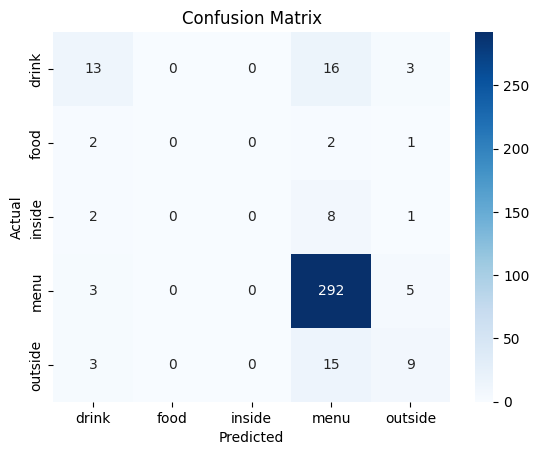

AUC Score: 0.907886146189524
Classification Report:
              precision    recall  f1-score   support

       drink       0.57      0.41      0.47        32
        food       0.00      0.00      0.00         5
      inside       0.00      0.00      0.00        11
        menu       0.88      0.97      0.92       300
     outside       0.47      0.33      0.39        27

    accuracy                           0.84       375
   macro avg       0.38      0.34      0.36       375
weighted avg       0.78      0.84      0.81       375



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [26]:
print("CNN Model tunning Round")
model1 = build_model(filters=32, dense_units=64, dropout=0.3)
history1 = model1.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=2)
train_acc1 = history1.history['accuracy'][-1]
print("Training Accuracy:", train_acc1)
evaluate(model1, X_test, y_test)

After tunning ouur model first time with (filters=32, dense_units=64, dropout=0.3),Our model has training accuracy of 0.839 and tes accuracy of 0.837  with AUC value of 0.907

2nd Round of tunning of CNN Model

CNN Model tunning Round 2


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
43/43 - 22s - 512ms/step - accuracy: 0.7782 - loss: 0.7820 - val_accuracy: 0.8333 - val_loss: 0.7624
Epoch 2/5
43/43 - 18s - 428ms/step - accuracy: 0.8027 - loss: 0.6628 - val_accuracy: 0.8467 - val_loss: 0.5573
Epoch 3/5
43/43 - 20s - 473ms/step - accuracy: 0.8279 - loss: 0.5298 - val_accuracy: 0.8467 - val_loss: 0.4774
Epoch 4/5
43/43 - 20s - 474ms/step - accuracy: 0.8331 - loss: 0.4780 - val_accuracy: 0.8467 - val_loss: 0.4915
Epoch 5/5
43/43 - 20s - 473ms/step - accuracy: 0.8665 - loss: 0.3963 - val_accuracy: 0.8600 - val_loss: 0.4821
Training Accuracy: 0.8664688467979431
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step
Test Accuracy: 0.848


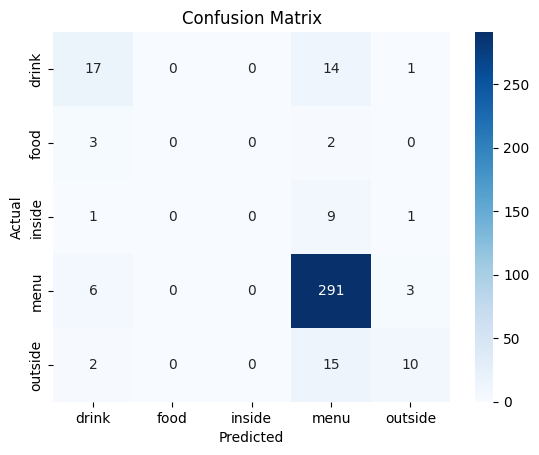

AUC Score: 0.9220787948326723
Classification Report:
              precision    recall  f1-score   support

       drink       0.59      0.53      0.56        32
        food       0.00      0.00      0.00         5
      inside       0.00      0.00      0.00        11
        menu       0.88      0.97      0.92       300
     outside       0.67      0.37      0.48        27

    accuracy                           0.85       375
   macro avg       0.43      0.37      0.39       375
weighted avg       0.80      0.85      0.82       375



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
print("CNN Model tunning Round 2")
model2 = build_model(filters=64, dense_units=128, dropout=0.4)
history2 = model2.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=2)
train_acc2 = history2.history['accuracy'][-1]
print("Training Accuracy:", train_acc2)
evaluate(model2, X_test, y_test)


After tunning the model second time with (filters=64, dense_units=128, dropout=0.4), we got our training accuracy increased to 0.866 and testing accuracy to 0.848. We have our AUC also increased to 0.922


3rd Round of tunning for CNN model

CNN Model tunning Round 3


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
43/43 - 53s - 1s/step - accuracy: 0.7804 - loss: 0.7843 - val_accuracy: 0.8267 - val_loss: 0.6871
Epoch 2/5
43/43 - 81s - 2s/step - accuracy: 0.8056 - loss: 0.6800 - val_accuracy: 0.8333 - val_loss: 0.5607
Epoch 3/5
43/43 - 80s - 2s/step - accuracy: 0.8272 - loss: 0.5663 - val_accuracy: 0.8467 - val_loss: 0.5352
Epoch 4/5
43/43 - 85s - 2s/step - accuracy: 0.8331 - loss: 0.4969 - val_accuracy: 0.8533 - val_loss: 0.5328
Epoch 5/5
43/43 - 49s - 1s/step - accuracy: 0.8657 - loss: 0.4124 - val_accuracy: 0.8667 - val_loss: 0.4434
Training Accuracy: 0.8657270073890686
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step
Test Accuracy: 0.832


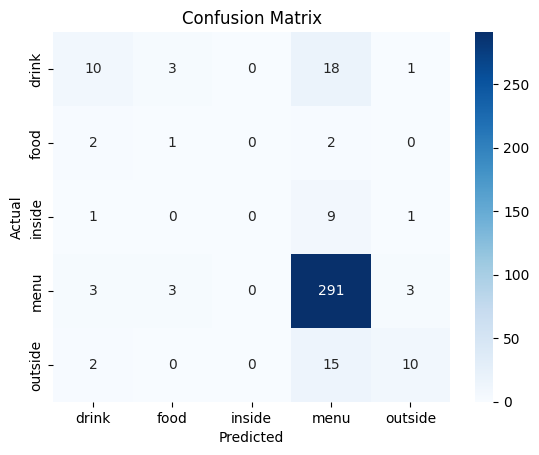

AUC Score: 0.91467970585645
Classification Report:
              precision    recall  f1-score   support

       drink       0.56      0.31      0.40        32
        food       0.14      0.20      0.17         5
      inside       0.00      0.00      0.00        11
        menu       0.87      0.97      0.92       300
     outside       0.67      0.37      0.48        27

    accuracy                           0.83       375
   macro avg       0.45      0.37      0.39       375
weighted avg       0.79      0.83      0.80       375



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
print("CNN Model tunning Round 3")
model3 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(lb.classes_), activation='softmax')
])
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history3 = model3.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=2)
train_acc3 = history3.history['accuracy'][-1]
print("Training Accuracy:", train_acc3)
evaluate(model3, X_test, y_test)

After tunning the model for the third time, we got a slight drop in accuracy and AUC. The train accuracy is 0.865, test accuracy is 0.832, and AUC is 0.914

In [29]:
# Saving the best model
model3.save("/content/drive/MyDrive/cnn_best_model.h5")

Chat GPT Prompts:

1st Prompt: I have a yelp image datasets, show me the codes for CNN model and tunning for the model
2nd Prompt: Show me code to save the best model